# 1 — Fit LG to a single real network (SNAP ego graph)

End-to-end fit pipeline:

1. **Pick `d̂` via AIC** on the real graph using
   `select_d_ensemble(graphs=[adj], d_candidates=[0,1,2,3])` —
   the Layer-2 offset-logit AIC ($-2\,\ell\ell + 2$).
2. **Estimate `σ̂` via Layer-2 offset logit** at `d̂` using
   `estimate_sigma_from_graph(adj, d̂)`.
3. **Generate the LG sample** at `(d̂, σ̂)` using the corrected
   sampler (d=0 → direct ER; d≥1 → warm-started Layer-2 Gibbs with
   `β=1`).
4. **Compare against ER / WS / BA** via `GraphModelComparator`
   (spectral GIC, normalized-Laplacian KL).

**Default dataset:** Facebook ego network `3980` from the SNAP
`ego-Facebook` collection (`data/misc/facebook/3980.edges`).

Switch by editing the `DATASET` block in the second cell. The notebook
pre-wires the **five smallest Facebook ego nets** (sorted by |V|):

| key | file | |V| | |E| |
|---|---|---:|---:|
| `facebook_3980` | `3980.edges` | 52 | 146 |
| `facebook_698`  | `698.edges`  | 61 | 270 |
| `facebook_414`  | `414.edges`  | 150 | 1.7k |
| `facebook_686`  | `686.edges`  | 168 | 1.7k |
| `facebook_348`  | `348.edges`  | 224 | 3.2k |

Larger graphs (twitter ego nets, twitch communities) are listed but
will take longer per fit. Runtime scales mostly with the GIC grid
search and Gibbs sampling cost (~O(n²) per iter). The default
`facebook_3980` finishes in ~6 s; `facebook_348` in ~1 minute.

In [1]:
import os
for v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from logit_graph import (
    GraphModelComparator,
    LogitGraphFitter,
    calculate_graph_attributes,
    estimate_sigma_from_graph,
    select_d_ensemble,
)
from logit_graph.gic import GraphInformationCriterion

SEED = 0
np.random.seed(SEED)

# ---- DATASET selection ----------------------------------------------------
# Change DATASET to any of the keys below to switch networks.
# The five Facebook ego nets here are the smallest in the SNAP collection
# (by node count, computed from data/misc/facebook/*.edges).
DATA_ROOT = Path("..") / ".." / "data"
DATASETS = {
    # Facebook ego nets (smallest five — sorted by |V|)
    "facebook_3980": DATA_ROOT / "misc" / "facebook" / "3980.edges",  #  52 nodes
    "facebook_698":  DATA_ROOT / "misc" / "facebook" / "698.edges",   #  61 nodes
    "facebook_414":  DATA_ROOT / "misc" / "facebook" / "414.edges",   # 150 nodes
    "facebook_686":  DATA_ROOT / "misc" / "facebook" / "686.edges",   # 168 nodes
    "facebook_348":  DATA_ROOT / "misc" / "facebook" / "348.edges",   # 224 nodes
    # Other ego collections (untested in this fast notebook)
    "twitter_101859065": DATA_ROOT / "misc" / "twitter" / "101859065.edges",
    "twitter_10146102":  DATA_ROOT / "misc" / "twitter" / "10146102.edges",
    "twitch_ENGB":       DATA_ROOT / "twitch" / "graphs_processed" / "ENGB_graph.edges",
}
DATASET = "facebook_348"   # ← change me (any key in DATASETS)

edge_path = DATASETS[DATASET].resolve()
assert edge_path.is_file(), f"Missing dataset file: {edge_path}"

def _load_edges(path: Path) -> nx.Graph:
    G = nx.read_edgelist(path, nodetype=int)
    G = nx.Graph(G)                     # ensure undirected, no parallel edges
    G.remove_edges_from(nx.selfloop_edges(G))
    if G.number_of_nodes() == 0:
        raise ValueError(f"Empty graph loaded from {path}")
    # Take the largest connected component so spectrum/path-length attributes are well-defined.
    cc = max(nx.connected_components(G), key=len)
    return G.subgraph(cc).copy()

G_real = _load_edges(edge_path)
G_real = nx.convert_node_labels_to_integers(G_real)

print(f"DATASET={DATASET}  file={edge_path}")
print(
    f"  n={G_real.number_of_nodes()}, |E|={G_real.number_of_edges()}, "
    f"density={nx.density(G_real):.4f}"
)
print(calculate_graph_attributes(G_real))

DATASET=facebook_348  file=/Users/maruanottoni/home/master/research/all_logit/logit-graph/data/misc/facebook/348.edges
  n=224, |E|=3192, density=0.1278
{'nodes': 224, 'edges': 3192, 'density': 0.12780269058295965, 'avg_clustering': 0.5442814709697876, 'assortativity': 0.22269166051622483, 'num_components': 1, 'largest_component_size': 224, 'avg_path_length': 2.523462524023062, 'diameter': 9}


## 1. Pick LG parameters from the real graph

Both LG hyper-parameters are estimated **from the real graph itself**
using the model's own machinery:

- **`d̂`** is chosen via **AIC** (`select_d_ensemble`) over the
  candidates `[0, 1, 2, 3]`. The AIC minimises
  $-2\,\ell\ell + 2k$ for the Layer-2 offset-logit fit.
- **`σ̂`** is the offset-logit intercept at `d̂`
  (`estimate_sigma_from_graph(adj, d̂)`) — the same scalar reported in
  the AIC table.

Both helpers are the paper-consistent exports from
`logit_graph` (Layer-2 conditioning, `feature_mode="incremental"`).

In [2]:
adj_real = nx.to_numpy_array(G_real)
D_CANDIDATES = [0, 1, 2, 3]

d_hat, aic_stats = select_d_ensemble(
    graphs=[adj_real],
    d_candidates=D_CANDIDATES,
    feature_mode="incremental",
    extra_penalty_per_d=0.0,
)
sigma_hat = estimate_sigma_from_graph(adj_real, d_hat, feature_mode="incremental")

aic_rows = []
for d, s in aic_stats.items():
    aic_rows.append({
        "d": d,
        "AIC": s["aic"],
        "ll": s["ll"],
        "sigma_hat(d)": s["sigma_hat"],
        "n_obs": int(s["n_obs"]),
        "selected": "✓" if d == d_hat else "",
    })
aic_table = pd.DataFrame(aic_rows).set_index("d")

print(f"AIC-selected d̂ = {d_hat}")
print(f"σ̂ at d̂        = {sigma_hat:+.4f}")
aic_table.round(3)

AIC-selected d̂ = 1
σ̂ at d̂        = -3.2051


,AIC,ll,sigma_hat(d),n_obs,selected
d,,,,,
0,19093.068,-9545.534,-1.920,24976,
1,15035.470,-7516.735,-3.205,24976,✓
2,16974.199,-8486.099,-6.334,24976,
3,22152.066,-11075.033,-6.161,24976,


## 2. GIC-based comparison: LG (at AIC-selected `d̂`) vs ER / WS / BA

`GraphModelComparator` now fits **LG only at `d̂`** (chosen above via
AIC), while grid-searching the baselines (ER, WS, BA). Internally the
comparator re-estimates σ via the same Layer-2 offset logit, so its
LG `σ` should match `σ̂` from the previous cell. Lower spectral GIC =
better fit.

In [3]:
comparator = GraphModelComparator(
    d_list=[d_hat],            # LG fit only at the AIC-selected d̂
    lg_params={
        "max_iterations": 5000,
        "patience": 500,
        "edge_delta": None,
        "min_gic_threshold": 5,
        "er_p": 0.05,
        "check_interval": 50,
    },
    other_model_n_runs=2,
    dist_type="KL",
    verbose=False,
    other_models=["ER", "WS", "BA"],
    other_model_grid_points=5,
).compare(original_graph=G_real, graph_filepath=DATASET)

lg_md = comparator.fitted_graphs_data["LG"]["metadata"]
print(
    f"LG fit at d̂={d_hat}: comparator σ={lg_md['sigma']:+.4f} "
    f"vs offset-logit σ̂={sigma_hat:+.4f} "
    f"(|Δ|={abs(lg_md['sigma']-sigma_hat):.4f})"
)

summary = comparator.summary_df.copy()
display_cols = [
    "model", "param", "gic_value", "nodes", "edges", "density",
    "avg_clustering", "assortativity",
]
summary[display_cols].sort_values("gic_value")

Testing the selected model for ER
ER gic: 8.377775081639761
Testing the selected model for WS
WS gic: 5.485393954775654
Testing the selected model for BA
BA gic: 5.438274806417221
LG fit at d̂=1: comparator σ=-3.2051 vs offset-logit σ̂=-3.2051 (|Δ|=0.0000)


,model,param,gic_value,nodes,edges,density,avg_clustering,assortativity
1,LG,"d=1, sigma=-3.2051",5.251777,224,1075,0.043041,0.061924,-0.018328
2,BA,8.0,5.438275,224,1728,0.069186,0.161814,-0.096953
3,WS,80.1325,5.485394,224,3136,0.125561,0.120885,-0.019953
4,ER,0.19,8.377775,224,4643,0.185898,0.186657,-0.006548
0,Original,N/A,NaN,224,3192,0.127803,0.544281,0.222692


## 3. GIC bar chart

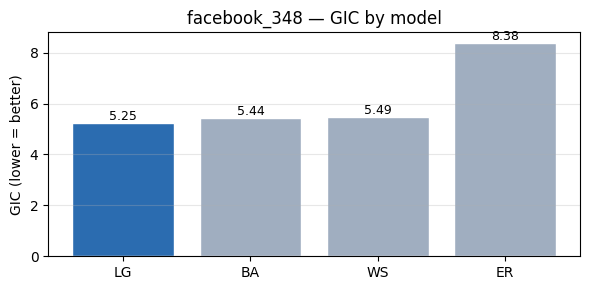

Best model by GIC: LG (param=d=1, sigma=-3.2051, GIC=5.252)


In [4]:
scored = summary[summary["model"] != "Original"].dropna(subset=["gic_value"])
scored = scored.sort_values("gic_value")

fig, ax = plt.subplots(figsize=(6.0, 3.0))
colors = ["#2b6cb0" if m == "LG" else "#a0aec0" for m in scored["model"]]
ax.bar(scored["model"], scored["gic_value"], color=colors, edgecolor="white")
for i, (m, v) in enumerate(zip(scored["model"], scored["gic_value"])):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("GIC (lower = better)")
ax.set_title(f"{DATASET} — GIC by model")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

best = scored.iloc[0]
print(f"Best model by GIC: {best['model']} (param={best['param']}, GIC={best['gic_value']:.3f})")

## 4. Side-by-side network layouts

The real graph is laid out once; every fitted graph uses the same
spring layout *over its own node set* so structural differences are
visually comparable but not over-aligned.

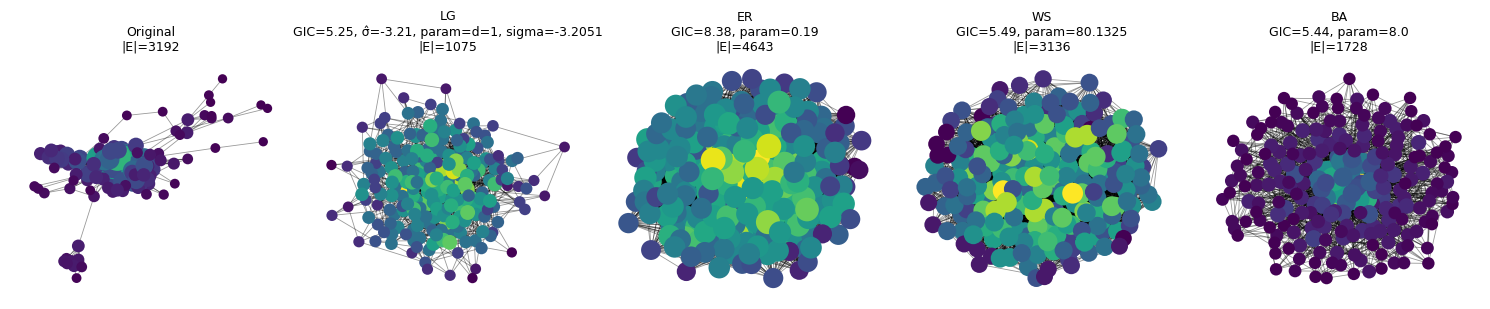

In [5]:
panels = [("Original", G_real)]
for name in ["LG", "ER", "WS", "BA"]:
    data = comparator.fitted_graphs_data.get(name, {})
    G_fit = data.get("graph")
    if G_fit is not None:
        panels.append((name, G_fit))

fig, axes = plt.subplots(1, len(panels), figsize=(3.0 * len(panels), 3.2))
if len(panels) == 1:
    axes = [axes]
for ax, (name, G) in zip(axes, panels):
    if G.number_of_edges() > 0:
        pos = nx.spring_layout(G, seed=42, k=None)
    else:
        pos = nx.circular_layout(G)
    deg = np.array([d for _, d in G.degree()])
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=0.6)
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=40 + 5 * deg, node_color=deg,
        cmap="viridis", linewidths=0.0,
    )
    md = comparator.fitted_graphs_data.get(name, {}).get("metadata", {})
    extras = []
    if "gic_value" in md and np.isfinite(md["gic_value"]):
        extras.append(f"GIC={md['gic_value']:.2f}")
    if "sigma" in md:
        extras.append(f"σ̂={md['sigma']:.2f}")
    if name != "Original" and "param" in md:
        extras.append(f"param={md['param']}")
    title = name + ("\n" + ", ".join(extras) if extras else "")
    title += f"\n|E|={G.number_of_edges()}"
    ax.set_title(title, fontsize=9)
    ax.set_axis_off()
fig.tight_layout()
plt.show()

## 5. Normalized-Laplacian spectral density

Each model graph is overlaid against the real graph's spectral density.
Closer overlap with the real (black) curve ↔ smaller spectral distance
↔ smaller GIC.

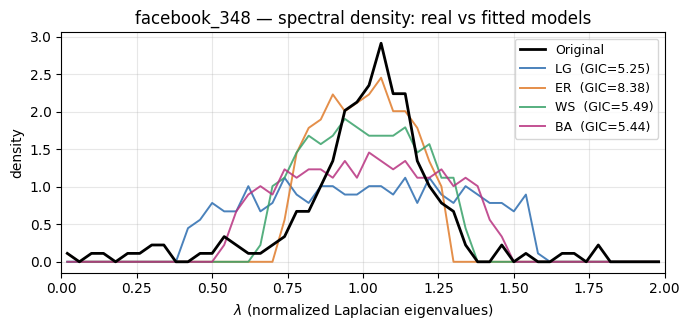

In [6]:
def spectral_density(G: nx.Graph) -> tuple[np.ndarray, np.ndarray]:
    gic = GraphInformationCriterion(graph=G, model="LG", log_graph=G, dist="KL")
    hist, bin_edges = gic.compute_spectral_density(G)
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    return centers, hist

x_real, y_real = spectral_density(G_real)

fig, ax = plt.subplots(figsize=(7.0, 3.4))
ax.plot(x_real, y_real, color="black", lw=2.0, label="Original", zorder=5)

palette = {"LG": "#2b6cb0", "ER": "#e07b2a", "WS": "#38a169", "BA": "#b83280"}
for name in ["LG", "ER", "WS", "BA"]:
    G = comparator.fitted_graphs_data.get(name, {}).get("graph")
    if G is None or G.number_of_edges() == 0:
        continue
    x, y = spectral_density(G)
    gic_v = comparator.fitted_graphs_data[name]["metadata"].get("gic_value", float("nan"))
    ax.plot(x, y, color=palette[name], lw=1.4, alpha=0.85,
            label=f"{name}  (GIC={gic_v:.2f})")

ax.set_xlim(0, 2)
ax.set_xlabel(r"$\lambda$ (normalized Laplacian eigenvalues)")
ax.set_ylabel("density")
ax.set_title(f"{DATASET} — spectral density: real vs fitted models")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Final scoreboard

GIC, density, average clustering, and assortativity for each model
ranked by GIC.

In [7]:
real_attrs = {
    "density": nx.density(G_real),
    "avg_clustering": nx.average_clustering(G_real),
    "assortativity": nx.degree_assortativity_coefficient(G_real),
}

rows = [{
    "model": "Original",
    "gic": np.nan,
    "edges": G_real.number_of_edges(),
    "density": real_attrs["density"],
    "avg_clustering": real_attrs["avg_clustering"],
    "assortativity": real_attrs["assortativity"],
    "Δdensity": 0.0,
    "Δclustering": 0.0,
}]
for name in ["LG", "ER", "WS", "BA"]:
    data = comparator.fitted_graphs_data.get(name, {})
    G = data.get("graph")
    if G is None:
        continue
    a = {
        "density": nx.density(G),
        "avg_clustering": nx.average_clustering(G),
        "assortativity": nx.degree_assortativity_coefficient(G),
    }
    rows.append({
        "model": name,
        "gic": data["metadata"].get("gic_value", np.nan),
        "edges": G.number_of_edges(),
        "density": a["density"],
        "avg_clustering": a["avg_clustering"],
        "assortativity": a["assortativity"],
        "Δdensity": a["density"] - real_attrs["density"],
        "Δclustering": a["avg_clustering"] - real_attrs["avg_clustering"],
    })

scoreboard = pd.DataFrame(rows)
scoreboard = pd.concat(
    [scoreboard[scoreboard["model"] == "Original"],
     scoreboard[scoreboard["model"] != "Original"].sort_values("gic")],
    ignore_index=True,
)
scoreboard.round(4)

,model,gic,edges,density,avg_clustering,assortativity,Δdensity,Δclustering
0,Original,NaN,3192,0.1278,0.5443,0.2227,0.0000,0.0000
1,LG,5.2518,1075,0.0430,0.0619,-0.0183,-0.0848,-0.4824
2,BA,5.4383,1728,0.0692,0.1618,-0.0970,-0.0586,-0.3825
3,WS,5.4854,3136,0.1256,0.1209,-0.0200,-0.0022,-0.4234
4,ER,8.3778,4643,0.1859,0.1867,-0.0065,0.0581,-0.3576
